# MK vs RelCal pairwise angle comparison, mask 0
Pairwise MK angle differences $\alpha_i-\alpha_j$ from the MK chain against
the model-independent RelCal estimate $\Delta\alpha_{ij}$. Both derive from
the same 56 cross-spectra, so the naive quadrature error
$\sqrt{\sigma_{MK}^2+\sigma_{RelCal}^2}$ **overstates** the uncertainty of
the difference: it ignores their positive cross-covariance. This notebook
adds the analytic cross-covariance, computed by the delta method (both
estimators are linear functionals of the same binned Knox-covariant data
vector; no simulations needed), and reports the disagreement in units of
the corrected $\sigma$.

In [1]:
import os
for variable in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
                 'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ[variable] = '1'

%cd /global/homes/l/lonappan/workspace/cosmic_birefringence
#%pip install -e . -q
%matplotlib inline
import numpy as np
from cosmic_bire import CBlike
from cosmic_bire.relcal import RelCal
from cosmic_bire.analytic_cov import MKResponse, relcal_response, closure_covariance

config = 'configs/planck_hfi.yml'
mask = '0'
ref = '353B'
DEG = 180 / np.pi

rc = RelCal(config, mask=mask)
labels = [rc.map_label(k) for k in range(rc.nmaps)]
print('maps:', labels)

lh = CBlike(config)          # config['likelihood']['mask'] must equal `mask`
lh.precompute()
_ = lh.getdist_samples()
samples = lh.samples
mk_alpha = samples[:, 1:1 + rc.nmaps]
mk_mean = mk_alpha.mean(axis=0)
mk_cov = np.cov(mk_alpha.T)      # posterior covariance (for reference / sanity only)

pair_fits = rc.fit_all_pairs()

/global/u2/l/lonappan/workspace/cosmic_birefringence
maps: ['100A', '143A', '217A', '353A', '100B', '143B', '217B', '353B']
Using existing /global/homes/l/lonappan/pscratch/CBDATA/theory/beam_corrected_lcdm_spectra_100_143_217_353.npy
Using existing /global/homes/l/lonappan/pscratch/CBDATA/theory/psi_l_sigma15.npy
Number of alphas: 8
Using hfi/lfi ps mask with CO. Index: 0
Importing observed cl. Filename: /global/homes/l/lonappan/pscratch/CBDATA/spectra/raw/cl_mask_percent_0_freq_100_143_217_353.npy
Importing beam smoothed LCDM cl. Filename: /global/homes/l/lonappan/pscratch/CBDATA/theory/beam_corrected_lcdm_spectra_100_143_217_353.npy
Loading /global/homes/l/lonappan/pscratch/CBDATA/theory/psi_l_sigma15.npy
Loading saved covariance matrix. Filename: /global/homes/l/lonappan/pscratch/CBDATA/covariance/cov_bin_cl_hfi_mask_percent_0_100_143_217_353_lmin51_lmax1491.npy
Loaded 218368 samples directly from /global/homes/l/lonappan/pscratch/CBDATA/chains/planck_hfi_mask_0.h5
Removed no burn 

## Analytic response and Fisher cross-check
`MKResponse` linearizes the MK maximum-likelihood point around the posterior
mean, using the same model matrices (`get_A_B_primed_k`, dust $A_\ell$
included) and the same binned Knox covariance (`lh.analysis.obs_cov_bin`)
that built the chain. Its Fisher matrix should match minus the numerical
Hessian of the actual log-likelihood at that point; the printed ratio is a
sanity check that the linearization is being evaluated at the right point
before trusting the cross-covariance below.

In [2]:
n_A = int(lh.config['likelihood'].get('number_of_A', 4))
p_hat = np.concatenate(([samples[:,0].mean()], mk_mean, samples[:,1+rc.nmaps:1+rc.nmaps+n_A].mean(0)))
mkr = MKResponse(lh.analysis, p_hat, n_A=n_A)
print('Fisher condition number:', f'{mkr.condition:.2e}', '(large -> alpha-beta degeneracy weakly broken)')

# numerical-Hessian cross-check at the same point (slower; a few seconds)
import cosmic_bire.tools_fast as tf
def negll(p):
    beta = np.array([p[0]])
    alpha = p[1:1+rc.nmaps]
    if mkr.dust:
        A = p[1+rc.nmaps:]
        return -tf.likelihood_prob_model_eb(lh.analysis.c_l_o_bin, lh.analysis.c_l_th_bin,
            lh.analysis.obs_cov_bin, False, lh.analysis.number_of_bins, mkr.nob,
            alpha, beta, mkr.psi_l, A, mkr.turn_off)
    return -tf.likelihood_prob(lh.analysis.c_l_o_bin, lh.analysis.c_l_th_bin,
        lh.analysis.obs_cov_bin, False, lh.analysis.number_of_bins, mkr.nob, alpha, beta)
h = 1e-5; nd = mkr.ndim; H = np.zeros((nd, nd)); p0 = mkr.p_rad
for a in range(nd):
    for b in range(a, nd):
        ea, eb = np.eye(nd)[a]*h, np.eye(nd)[b]*h
        H[a,b] = H[b,a] = (negll(p0+ea+eb) - negll(p0+ea-eb) - negll(p0-ea+eb) + negll(p0-ea-eb)) / (4*h*h)
print('||F - H_num|| / ||F|| =', f'{np.max(np.abs(mkr.F - H)) / np.max(np.abs(mkr.F)):.2e}  (want << 1)')

Fisher condition number: 5.97e+04 (large -> alpha-beta degeneracy weakly broken)


/global/u2/l/lonappan/workspace/cosmic_birefringence/src/cosmic_bire/tools_fast.py:205: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  v = np.dot(A_mat, c_l_o) - np.dot(B_mat, c_l_th)
/global/u2/l/lonappan/workspace/cosmic_birefringence/src/cosmic_bire/tools_fast.py:207: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  A_Cov = np.dot(A_mat, obs_cov)
/global/u2/l/lonappan/workspace/cosmic_birefringence/src/cosmic_bire/tools_fast.py:207: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  A_Cov = np.dot(A_mat, obs_cov)


||F - H_num|| / ||F|| = 2.29e-03  (want << 1)


## Chain self-consistency diagnostic
The closure covariance below linearizes the MK maximum-likelihood point at the chain's posterior mean using its Fisher matrix. This is only valid if the chain's own posterior covariance agrees with that Fisher prediction (Gaussian, well-converged posterior). If the ratio deviates far from 1, treat the analytic closure chi2 below with caution and prefer the pairwise z_corr table instead, which uses the chain covariance directly.

In [3]:
chain_sigma = np.sqrt(np.diag(mk_cov)) * DEG if False else np.sqrt(np.diag(mk_cov))
fisher_sigma = np.sqrt(np.diag(mkr.Finv[1:1+rc.nmaps, 1:1+rc.nmaps])) * DEG
print(f'{"map":5s} {"chain sigma":>12s} {"Fisher sigma":>13s} {"ratio":>7s}')
ratio = chain_sigma / fisher_sigma
for k, lab in enumerate(labels):
    print(f'{lab:5s} {chain_sigma[k]:12.4f} {fisher_sigma[k]:13.4f} {ratio[k]:7.2f}')
print(f'\nratio range: [{ratio.min():.2f}, {ratio.max():.2f}]  (want close to 1)')
if not (0.5 < ratio.min() and ratio.max() < 2.0):
    print('WARNING: chain and Fisher sigmas disagree by >2x for at least one map;')
    print('the closure chi2 in the next section may not be reliable.')


map    chain sigma  Fisher sigma   ratio
100A        0.1355        0.1386    0.98
143A        0.1162        0.1200    0.97
217A        0.1105        0.1136    0.97
353A        0.1083        0.1122    0.97
100B        0.1318        0.1339    0.98
143B        0.1166        0.1198    0.97
217B        0.1099        0.1136    0.97
353B        0.1093        0.1126    0.97

ratio range: [0.97, 0.98]  (want close to 1)


## Pairwise comparison with the analytic cross-covariance
$\sigma_{{\rm corrected}}^2 = \sigma_{{MK}}^2+\sigma_{{RelCal}}^2-2\,\mathrm{{Cov}}(\alpha^{{MK}}_i-\alpha^{{MK}}_j,\ \Delta\hat\alpha_{{ij}})$,
with the cross term from `mkr.cov_with(Rrel)`, itself a sum over bins of the
analytic response matrices contracted with the same `obs_cov_bin`.

In [4]:
Rrel, _ = relcal_response(rc, ref=None)          # sum-zero gauge network response
C_mk_full = mkr.Finv[1:1+rc.nmaps, 1:1+rc.nmaps]          # Fisher alpha-alpha block, rad^2
C_rel_full = sum(Rrel[b] @ lh.analysis.obs_cov_bin[b] @ Rrel[b].T for b in range(rc.n_bins))
X_full = mkr.cov_with(Rrel)                                # Cov(alpha_MK, alpha_rel), rad^2
alpha_rel_full, _, _ = rc.fit_network(ref=None)

def idx(label):
    return labels.index(label)

print(f'{"pair":12s} {"MK ai-aj":>20s} {"RelCal":>20s} {"sigma quad":>10s} {"sigma corr":>10s} {"z quad":>8s} {"z corr":>8s}')
rows = []
for (a, b), (delta_alpha, delta_sigma) in pair_fits.items():
    ia, ib = idx(a), idx(b)
    mk_value = mk_mean[ia] - mk_mean[ib]
    mk_sigma = np.sqrt(mk_cov[ia,ia] + mk_cov[ib,ib] - 2*mk_cov[ia,ib])
    diff = mk_value - delta_alpha
    var_quad = mk_sigma**2 + delta_sigma**2
    # cross-covariance of (alpha_MK_a - alpha_MK_b) with (alpha_rel_a - alpha_rel_b), in deg^2
    e = np.zeros(rc.nmaps); e[ia] = 1; e[ib] = -1
    cross = float(e @ X_full @ e) * DEG**2
    var_corr = var_quad - 2*cross
    var_corr = max(var_corr, 1e-8)   # guard tiny negative from numerical noise
    z_quad = diff / np.sqrt(var_quad) if var_quad > 0 else np.nan
    z_corr = diff / np.sqrt(var_corr)
    rows.append((a, b, mk_value, mk_sigma, delta_alpha, delta_sigma, z_quad, z_corr))
    print(f'{a}-{b:8s} {mk_value:+9.4f}+-{mk_sigma:5.4f}  {delta_alpha:+9.4f}+-{delta_sigma:5.4f}  '
          f'{np.sqrt(var_quad):8.4f}  {np.sqrt(var_corr):8.4f}  {z_quad:+6.2f}  {z_corr:+6.2f}')

zc = np.array([r[7] for r in rows])
print(f'\nworst |z_corrected| = {np.max(np.abs(zc)):.2f}  (mean {zc.mean():+.2f}, std {zc.std():.2f})')

pair                     MK ai-aj               RelCal sigma quad sigma corr   z quad   z corr
100A-143A       -0.3423+-0.0890    -0.3066+-0.1199    0.1494    0.0812   -0.24   -0.44
100A-217A       -0.2559+-0.0859    -0.3552+-0.1307    0.1564    0.0979   +0.63   +1.01
100A-353A       -0.1295+-0.0868    -0.0880+-0.1688    0.1898    0.1452   -0.22   -0.29
100A-100B       +0.1052+-0.1022    +0.1051+-0.1487    0.1804    0.1087   +0.00   +0.00
100A-143B       -0.4623+-0.0881    -0.4522+-0.1168    0.1463    0.0776   -0.07   -0.13
100A-217B       -0.2360+-0.0869    -0.2327+-0.1303    0.1566    0.0982   -0.02   -0.03
100A-353B       -0.0922+-0.0876    -0.2231+-0.1741    0.1949    0.1509   +0.67   +0.87
143A-217A       +0.0864+-0.0529    +0.1359+-0.0650    0.0838    0.0361   -0.59   -1.37
143A-353A       +0.2128+-0.0524    +0.2019+-0.0704    0.0878    0.0465   +0.12   +0.23
143A-100B       +0.4474+-0.0819    +0.4835+-0.1088    0.1362    0.0723   -0.27   -0.50
143A-143B       -0.1200+-0.0594    

## Network closure statistic
Full $d=P(\hat\alpha_{{\rm rel}}-\alpha^{{MK}})$ with the analytic covariance
and its $\chi^2$ over the network's degrees of freedom.

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

Reference map: 353B
map      d [deg]   z (analytic)
100A     +0.0472          +1.26
143A     +0.0024          +0.12
217A     +0.0079          +1.31
353A     -0.0006          -0.40
100B     +0.0353          +1.02
143B     +0.0315          +1.69
217B     +0.0007          +0.12
353B     +0.0000          +0.00

closure chi2 = 8.18  (dof = 7)


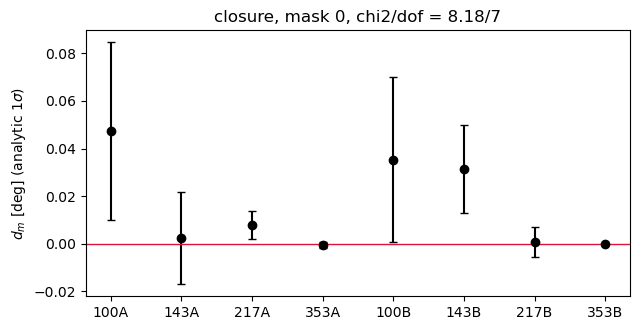

In [5]:
res = closure_covariance(rc, mkr, mk_mean, ref=labels.index(ref))  # mk_mean already in degrees
print(f'Reference map: {ref}')
print(f'{"map":5s} {"d [deg]":>10s} {"z (analytic)":>14s}')
for k, lab in enumerate(res['labels']):
    print(f'{lab:5s} {res["d"][k]:+10.4f} {res["z"][k]:+14.2f}')
print(f'\nclosure chi2 = {res["chi2"]:.2f}  (dof = {res["dof"]})')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6.5, 3.4))
x = np.arange(rc.nmaps)
ax.errorbar(x, res['d'], np.sqrt(np.abs(np.diag(res['cov_d']))), fmt='o', capsize=3, color='k')
ax.axhline(0, color='crimson', lw=1)
ax.set_xticks(x); ax.set_xticklabels(res['labels'])
ax.set_ylabel(r'$d_m$ [deg] (analytic $1\sigma$)')
ax.set_title(f'closure, mask {mask}, chi2/dof = {res["chi2"]:.2f}/{res["dof"]}')
fig.tight_layout()
fig.savefig(rc.paths['plots'] / f'mk_relcal_closure_analytic_mask_{mask}.pdf')

## Compact summary table in the chosen gauge

In [6]:
ref_idx = labels.index(ref)
mk_rel = mk_mean - mk_mean[ref_idx]
rel_ref, rel_cov, _ = rc.fit_network(ref=ref_idx)
rel_err = np.sqrt(np.abs(np.diag(rel_cov)))
mk_rel_err = np.sqrt(np.abs(np.diag(C_mk_full)*DEG**2 + C_mk_full[ref_idx,ref_idx]*DEG**2
                            - 2*C_mk_full[:,ref_idx]*DEG**2))

print(f'Reference map: {ref}')
print(f'{"map":5s} {"MK a-a_ref":>16s} {"RelCal a-a_ref":>18s} {"d (analytic sigma)":>22s}')
for k, lab in enumerate(labels):
    print(f'{lab:5s} {mk_rel[k]:+10.4f}+-{mk_rel_err[k]:5.4f}  {rel_ref[k]:+10.4f}+-{rel_err[k]:5.4f}  '
          f'{res["d"][k]:+10.4f} ({res["z"][k]:+.2f}sigma)')

Reference map: 353B
map         MK a-a_ref     RelCal a-a_ref     d (analytic sigma)
100A     -0.0922+-0.0873     -0.0450+-0.0969     +0.0472 (+1.26sigma)
143A     +0.2500+-0.0540     +0.2524+-0.0605     +0.0024 (+0.12sigma)
217A     +0.1636+-0.0323     +0.1715+-0.0381     +0.0079 (+1.31sigma)
353A     +0.0372+-0.0230     +0.0367+-0.0302     -0.0006 (-0.40sigma)
100B     -0.1974+-0.0803     -0.1621+-0.0896     +0.0353 (+1.02sigma)
143B     +0.3700+-0.0528     +0.4015+-0.0592     +0.0315 (+1.69sigma)
217B     +0.1438+-0.0323     +0.1445+-0.0382     +0.0007 (+0.12sigma)
353B     +0.0000+-0.0000     +0.0000+-0.0194     +0.0000 (+0.00sigma)
